# Assam Flood Impact Prediction — Machine Learning Modelling

## 1. Data Loading & Final Dataset Verification

## 2. Final 20 Feature Set

## 3. Target Variable & Class Distribution

## 4. Pattern Analysis & Visualization

## 5. Feature–Target Relationship Analysis

## 6. Temporal Train-Test Split

## 7. Class Imbalance Handling

## 8. Baseline Model

## 9. Machine Learning Model Training

* CatBoost
* XGBoost
* Random Forest

## 10. Model Evaluation

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

## 11. Overfitting & Train-Test Performance Analysis

## 12. Confusion Matrix & Prediction Analysis

## 13. Feature Importance Analysis

## 14. Best Model Selection & Saving

## 15. Modelling Conclusions & Next Stage




#Assam Flood Impact Prediction — Machine Learning Modelling


Environment and Data Loading

#1.Import all Libraries

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
!pip install catboost xgboost -q


In [5]:
from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

#Mount Google Drive

In [6]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


#load the dataset

In [7]:
import pandas as pd

# Corrected URL to the raw CSV file on GitHub
url = "https://raw.githubusercontent.com/Samriddhi330/Assam-Flood-DSS/main/data/baseline_modeling_dataset_with_metadata.csv"

model_df = pd.read_csv(url)

print("Dataset loaded successfully!")

print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

Dataset loaded successfully!
Rows: 10980
Columns: 23


In [8]:
print("Column names:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nDataset Shape:")
print(model_df.shape)



Column names:
['object_id', 'timeperiod', 'max_rain', 'mean_rain', 'sum_rain', 'mean_ndvi', 'mean_ndbi', 'sum_population', 'sum_aged_population', 'sum_young_population', 'mean_sex_ratio', 'total_hhd', 'net_sown_area_in_hac', 'schools_count', 'health_centres_count', 'road_length', 'distance_from_river', 'drainage_density', 'elevation_mean', 'slope_mean', 'mean_cn', 'impact', 'next_month_impact']

First 5 rows:


,object_id,timeperiod,max_rain,mean_rain,sum_rain,mean_ndvi,mean_ndbi,sum_population,sum_aged_population,sum_young_population,...,schools_count,health_centres_count,road_length,distance_from_river,drainage_density,elevation_mean,slope_mean,mean_cn,impact,next_month_impact
0,18-300-00101,2021_04,0.214262,0.171746,166.249990,0.367604,0.001127,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
1,18-300-00101,2021_05,0.344883,0.310867,300.919378,0.483602,-0.060225,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
2,18-300-00101,2021_06,1.346394,0.944965,914.725700,0.567028,-0.147426,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
3,18-300-00101,2021_07,0.975052,0.814687,788.617197,0.662550,-0.157022,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
4,18-300-00101,2021_08,1.308983,0.822254,795.942200,0.662550,-0.157022,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0



Dataset Shape:
(10980, 23)


In [9]:
target = "next_month_impact"

features = [
    column
    for column in model_df.columns
    if column != target
]

X = model_df[features].copy()
y = model_df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 22
X shape: (10980, 22)
y shape: (10980,)


Check missing values

In [10]:
missing_values = model_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing values in each column:
object_id               0
timeperiod              0
max_rain                0
mean_rain               0
sum_rain                0
mean_ndvi               0
mean_ndbi               0
sum_population          0
sum_aged_population     0
sum_young_population    0
mean_sex_ratio          0
total_hhd               0
net_sown_area_in_hac    0
schools_count           0
health_centres_count    0
road_length             0
distance_from_river     0
drainage_density        0
elevation_mean          0
slope_mean              0
mean_cn                 0
impact                  0
next_month_impact       0
dtype: int64

Total missing values:
0


#Check target distribution

In [11]:
print("Target Distribution:")
print(y.value_counts())

print("\nTarget Percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Target Distribution:
next_month_impact
0.0    10103
1.0      877
Name: count, dtype: int64

Target Percentage:
next_month_impact
0.0    92.01
1.0     7.99
Name: proportion, dtype: float64


#Target distribution chart

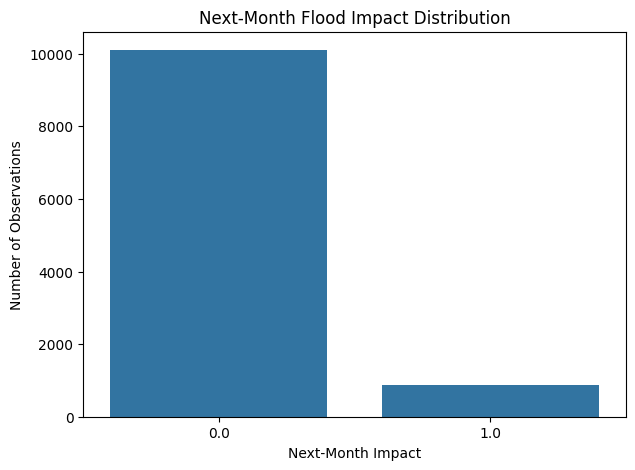

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y
)

plt.title(
    "Next-Month Flood Impact Distribution"
)

plt.xlabel(
    "Next-Month Impact"
)

plt.ylabel(
    "Number of Observations"
)

plt.show()

#Feature statistics

In [13]:
print("Summary Statistics of the 20 Features:")

display(
    X.describe().T
)

Summary Statistics of the 20 Features:


,count,mean,std,min,25%,50%,75%,max
max_rain,10980.0,0.328544,0.364511,0.000000,0.033535,0.234592,0.497069,2.780199
mean_rain,10980.0,0.273258,0.310130,0.000000,0.023715,0.189438,0.409772,2.681264
sum_rain,10980.0,102.875236,160.479522,0.000000,4.243437,41.973334,134.167396,2113.367071
mean_ndvi,10980.0,0.472135,0.136757,-0.098735,0.391052,0.485502,0.561583,0.887988
mean_ndbi,10980.0,-0.122881,0.092064,-0.579713,-0.185600,-0.125146,-0.054974,0.128507
sum_population,10980.0,200339.092482,136607.397268,147.727197,106905.579687,174818.996875,270639.153125,771952.975000
sum_aged_population,10980.0,9458.244612,7572.323716,0.594000,3713.937000,7641.262000,13837.884000,49578.404000
sum_young_population,10980.0,16528.075393,13877.284290,1.076000,6344.075750,12336.377000,22907.721000,76635.776000
mean_sex_ratio,10980.0,0.936880,0.009516,0.903430,0.930781,0.938058,0.942053,0.955698
total_hhd,10980.0,43846.600000,34724.357659,0.000000,21471.000000,38531.000000,56887.500000,257725.000000


#Feature distributions

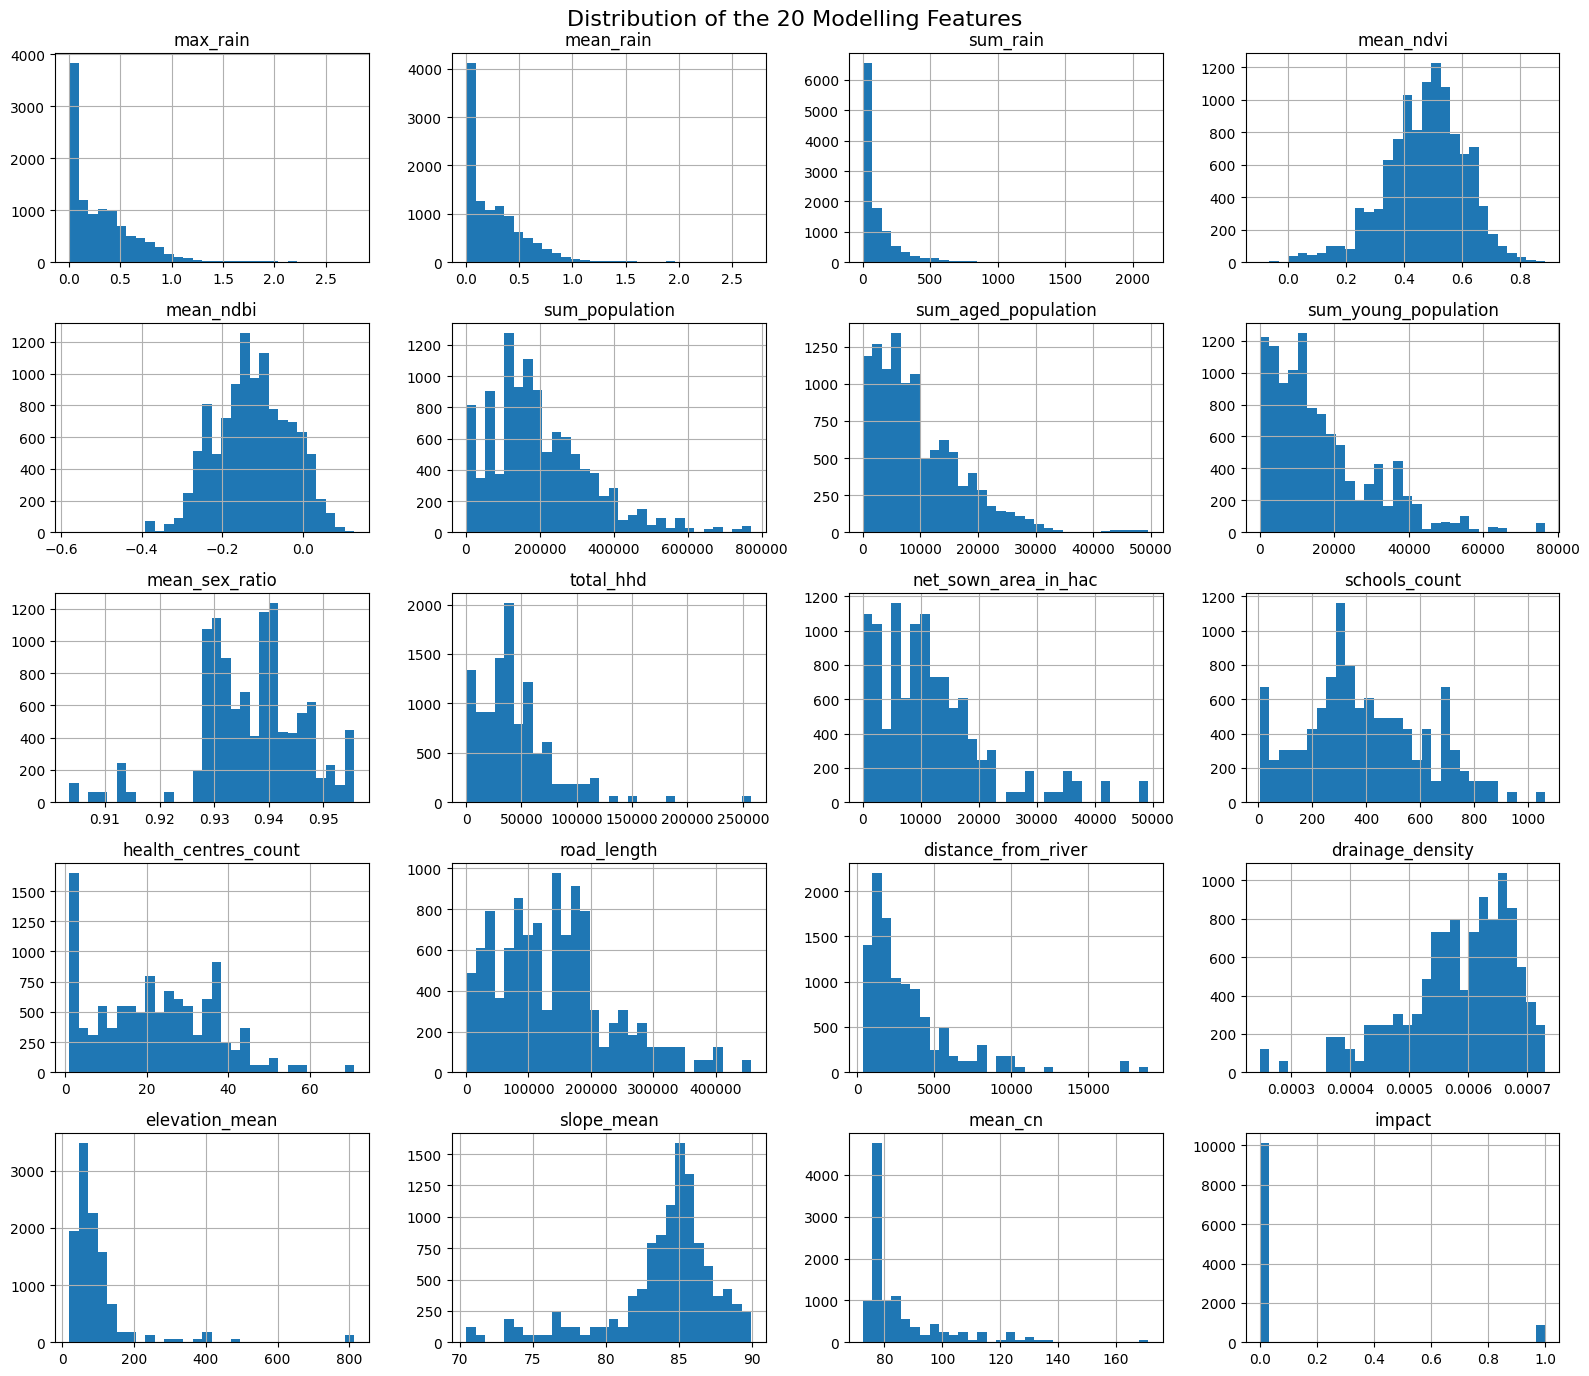

In [14]:
X.hist(
    figsize=(16, 14),
    bins=30
)

plt.suptitle(
    "Distribution of the 20 Modelling Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

#Correlation with target

In [15]:
numeric_features = [col for col in features if col not in ['object_id', 'timeperiod']]

target_correlation = (
    model_df[numeric_features + [target]]
    .corr()[target]
    .drop(target)
    .sort_values()
)

print(
    "Correlation of Features with Next-Month Impact:"
)

display(
    target_correlation.to_frame(
        name="Correlation"
    )
)

Correlation of Features with Next-Month Impact:


,Correlation
slope_mean,-0.069392
mean_ndvi,-0.046478
elevation_mean,-0.023281
distance_from_river,0.001199
mean_sex_ratio,0.022822
drainage_density,0.026773
mean_cn,0.031802
mean_ndbi,0.038684
total_hhd,0.070280
sum_young_population,0.071590


#Correlation chart

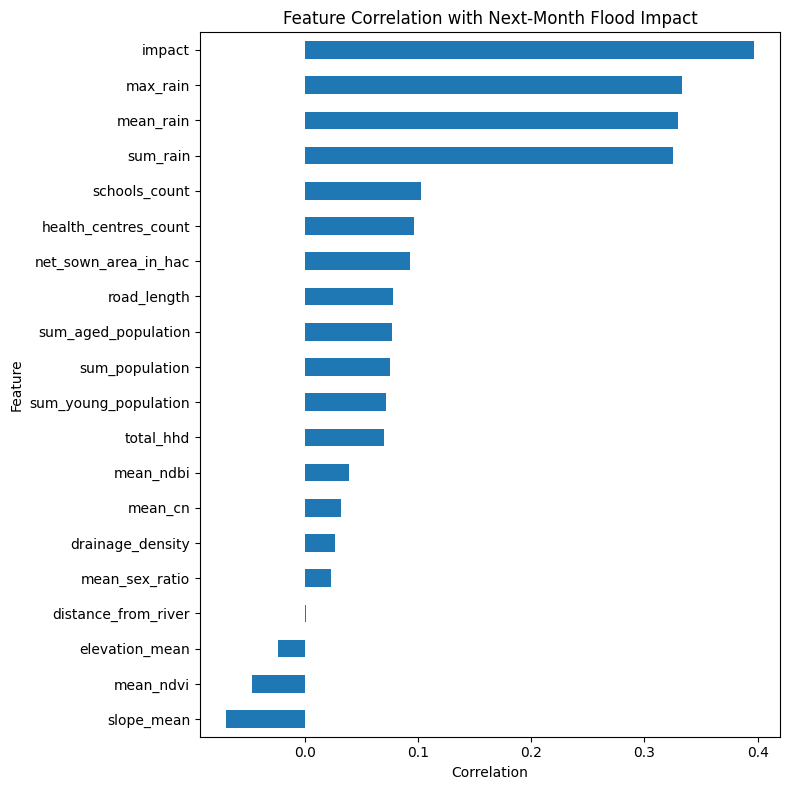

In [16]:
plt.figure(figsize=(8, 8))

target_correlation.plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Next-Month Flood Impact"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [17]:
print("Dataset columns:")

for i, column in enumerate(model_df.columns, start=1):
    print(i, column)

Dataset columns:
1 object_id
2 timeperiod
3 max_rain
4 mean_rain
5 sum_rain
6 mean_ndvi
7 mean_ndbi
8 sum_population
9 sum_aged_population
10 sum_young_population
11 mean_sex_ratio
12 total_hhd
13 net_sown_area_in_hac
14 schools_count
15 health_centres_count
16 road_length
17 distance_from_river
18 drainage_density
19 elevation_mean
20 slope_mean
21 mean_cn
22 impact
23 next_month_impact


In [18]:
target = "next_month_impact"

id_column = "object_id"

time_column = "timeperiod"

features = [
    "max_rain",
    "mean_rain",
    "sum_rain",
    "mean_ndvi",
    "mean_ndbi",
    "sum_population",
    "sum_aged_population",
    "sum_young_population",
    "mean_sex_ratio",
    "total_hhd",
    "net_sown_area_in_hac",
    "schools_count",
    "health_centres_count",
    "road_length",
    "distance_from_river",
    "drainage_density",
    "elevation_mean",
    "slope_mean",
    "mean_cn",
    "impact"
]

print("Number of modelling features:", len(features))

Number of modelling features: 20


In [19]:
required_columns = features + [
    id_column,
    time_column,
    target
]

missing_columns = [
    column
    for column in required_columns
    if column not in model_df.columns
]

if len(missing_columns) == 0:
    print("All required columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

All required columns are present.


In [20]:
model_df[time_column] = pd.to_datetime(
    model_df[time_column],
    format='%Y_%m'
)

print("Earliest date:")
print(model_df[time_column].min())

print("\nLatest date:")
print(model_df[time_column].max())

Earliest date:
2021-04-01 00:00:00

Latest date:
2026-04-01 00:00:00


In [21]:
model_df = model_df.sort_values(
    [time_column, id_column]
).reset_index(
    drop=True
)

print("Data sorted chronologically.")

Data sorted chronologically.


#Proper temporal train/test split

In [22]:
unique_months = sorted(
    model_df[time_column].dt.to_period("M").unique()
)

split_position = int(
    len(unique_months) * 0.80
)

train_months = unique_months[:split_position]

test_months = unique_months[split_position:]

print("Number of training months:", len(train_months))
print("Number of testing months:", len(test_months))

print("\nTraining period:")
print(train_months[0], "to", train_months[-1])

print("\nTesting period:")
print(test_months[0], "to", test_months[-1])

Number of training months: 48
Number of testing months: 13

Training period:
2021-04 to 2025-03

Testing period:
2025-04 to 2026-04


#Create train and test datasets

In [23]:
train_df = model_df[
    model_df[time_column].dt.to_period("M").isin(train_months)
].copy()

test_df = model_df[
    model_df[time_column].dt.to_period("M").isin(test_months)
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 8640
Testing rows: 2340


#Create X and y

In [24]:
X_train = train_df[features].copy()

X_test = test_df[features].copy()

y_train = train_df[target].astype(int).copy()

y_test = test_df[target].astype(int).copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8640, 20)
X_test : (2340, 20)
y_train: (8640,)
y_test : (2340,)


#Check class imbalance

In [25]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
next_month_impact
0    7901
1     739
Name: count, dtype: int64

Testing target distribution:
next_month_impact
0    2202
1     138
Name: count, dtype: int64


In [26]:
print("Training target percentage:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target percentage:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training target percentage:
next_month_impact
0    91.45
1     8.55
Name: proportion, dtype: float64

Testing target percentage:
next_month_impact
0    94.1
1     5.9
Name: proportion, dtype: float64


#Install required packages

In [27]:
!pip install -q catboost xgboost

# Import models and metrics

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#Calculate class weight

In [29]:
negative_count = (y_train == 0).sum()

positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 2)
)

Negative samples: 7901
Positive samples: 739
Scale positive weight: 10.69


#Model 1 — Logistic Regression

In [30]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model 2 — Random Forest




In [31]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


#Model 3 — XGBoost

In [32]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost training completed.")

XGBoost training completed.


#Model 4 — CatBoost

In [33]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

cat_pred = cat_model.predict(
    X_test
).astype(int).ravel()

cat_prob = cat_model.predict_proba(
    X_test
)[:, 1]

print("CatBoost training completed.")

CatBoost training completed.


#Compare all models

In [34]:
results = []

models = {
    "Logistic Regression": (logistic_pred, logistic_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "CatBoost": (cat_pred, cat_prob)
}

for model_name, (predictions, probabilities) in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.888034,0.272059,0.536232,0.360976,0.848191
3,CatBoost,0.852991,0.224599,0.608696,0.328125,0.856129
1,Random Forest,0.913248,0.300613,0.355072,0.325581,0.855795
0,Logistic Regression,0.783761,0.170251,0.688406,0.272989,0.805375


#Visual comparison

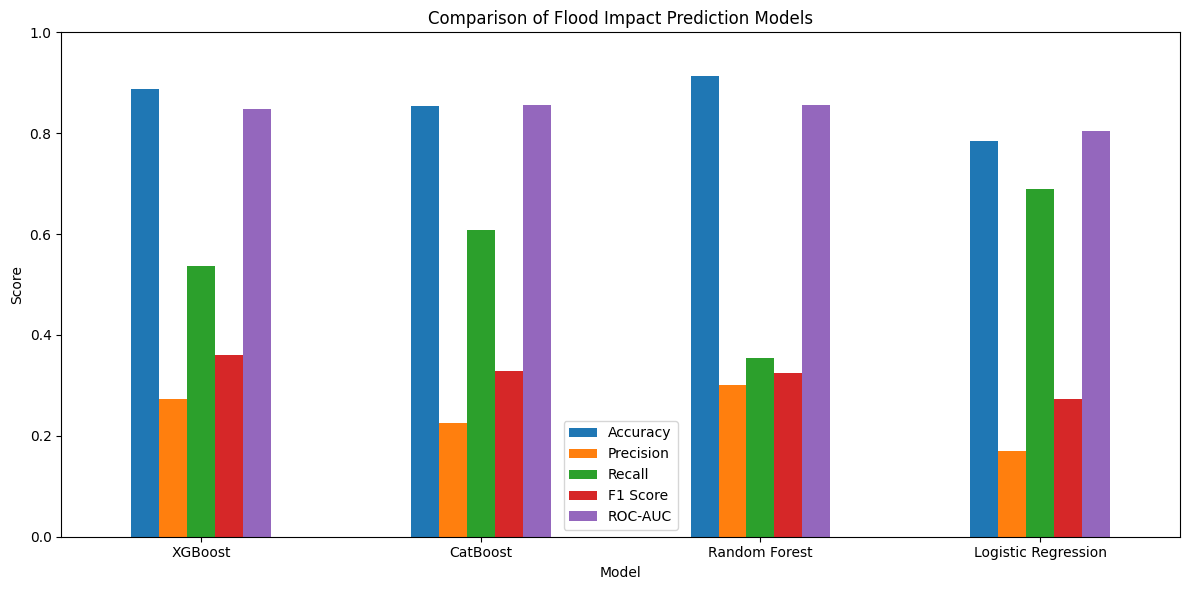

In [35]:
results_plot = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Comparison of Flood Impact Prediction Models"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.show()

#Find the best model

In [36]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best model based on F1 Score:",
    best_model_name
)

Best model based on F1 Score: XGBoost


#Detailed evaluation of CatBoost

In [37]:
print("CatBoost Classification Report")
print("--------------------------------")

print(
    classification_report(
        y_test,
        cat_pred,
        zero_division=0
    )
)

CatBoost Classification Report
--------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2202
           1       0.22      0.61      0.33       138

    accuracy                           0.85      2340
   macro avg       0.60      0.74      0.62      2340
weighted avg       0.93      0.85      0.88      2340



#Confusion Matrix

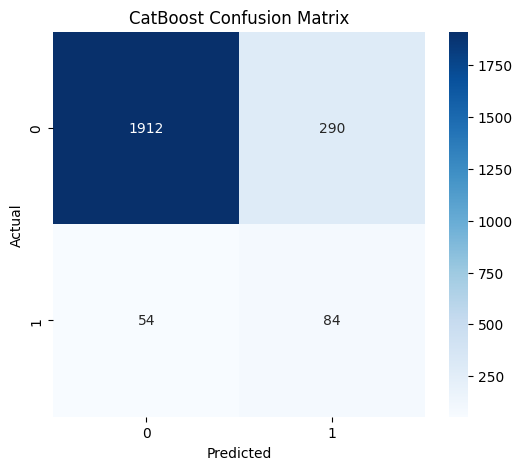

In [38]:
cm = confusion_matrix(
    y_test,
    cat_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "CatBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [39]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance
)

,Feature,Importance
0,max_rain,16.025248
1,mean_rain,12.332859
2,sum_rain,10.286147
4,mean_ndbi,8.554077
3,mean_ndvi,5.799959
16,elevation_mean,4.629164
8,mean_sex_ratio,4.556914
18,mean_cn,3.808341
10,net_sown_area_in_hac,3.612214
15,drainage_density,3.578748


#Feature importance chart

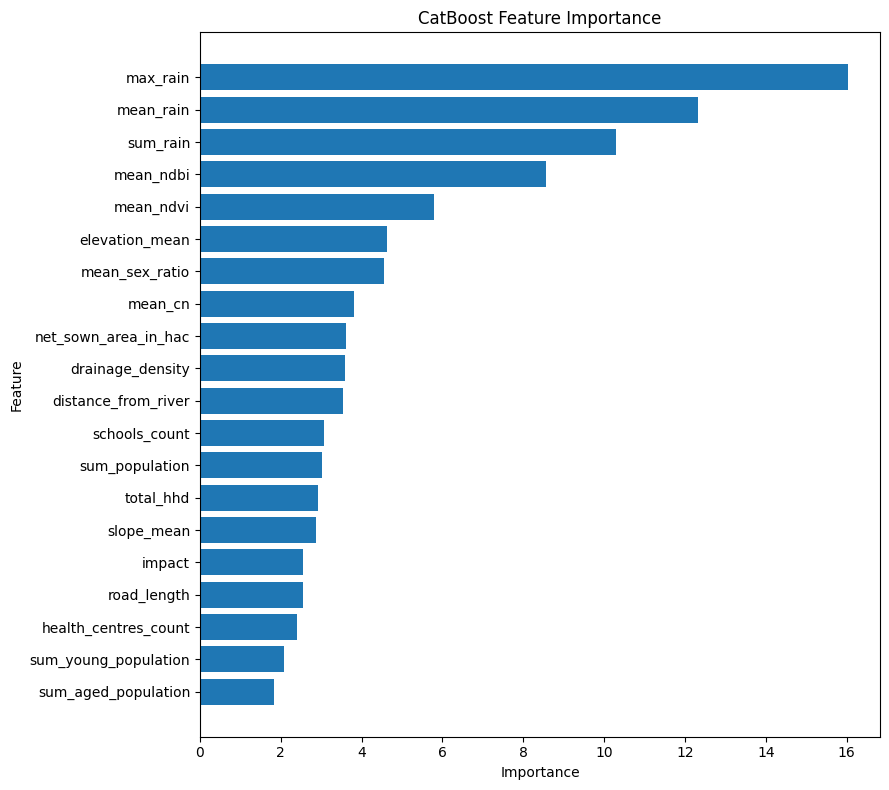

In [40]:
plt.figure(
    figsize=(9, 8)
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "CatBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

#Import Evaluation Metrics

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Store the Four Models

In [42]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

print("Models ready for evaluation:")

for name in models:
    print("-", name)

Models ready for evaluation:
- Logistic Regression
- Random Forest
- XGBoost
- CatBoost


#Evaluate All Models

In [43]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.783761,0.170251,0.688406,0.272989,0.805375
1,Random Forest,0.913248,0.300613,0.355072,0.325581,0.855795
2,XGBoost,0.888034,0.272059,0.536232,0.360976,0.848191
3,CatBoost,0.852991,0.224599,0.608696,0.328125,0.856129


#Display Results Clearly

In [44]:
results_display = results_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,78.38,17.03,68.84,27.30,80.54
1,Random Forest,91.32,30.06,35.51,32.56,85.58
2,XGBoost,88.80,27.21,53.62,36.10,84.82
3,CatBoost,85.30,22.46,60.87,32.81,85.61


#Classification Reports

In [45]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0     0.9759    0.7897    0.8730      2202
           1     0.1703    0.6884    0.2730       138

    accuracy                         0.7838      2340
   macro avg     0.5731    0.7391    0.5730      2340
weighted avg     0.9284    0.7838    0.8376      2340

Random Forest
              precision    recall  f1-score   support

           0     0.9591    0.9482    0.9536      2202
           1     0.3006    0.3551    0.3256       138

    accuracy                         0.9132      2340
   macro avg     0.6299    0.6517    0.6396      2340
weighted avg     0.9203    0.9132    0.9166      2340

XGBoost
              precision    recall  f1-score   support

           0     0.9691    0.9101    0.9386      2202
           1     0.2721    0.5362    0.3610       138

    accuracy                         0.8880      2340
   macro avg     0.6206    0.7232    0.6498      2340
weighted avg     0.9279    0.888

#Confusion Matrices

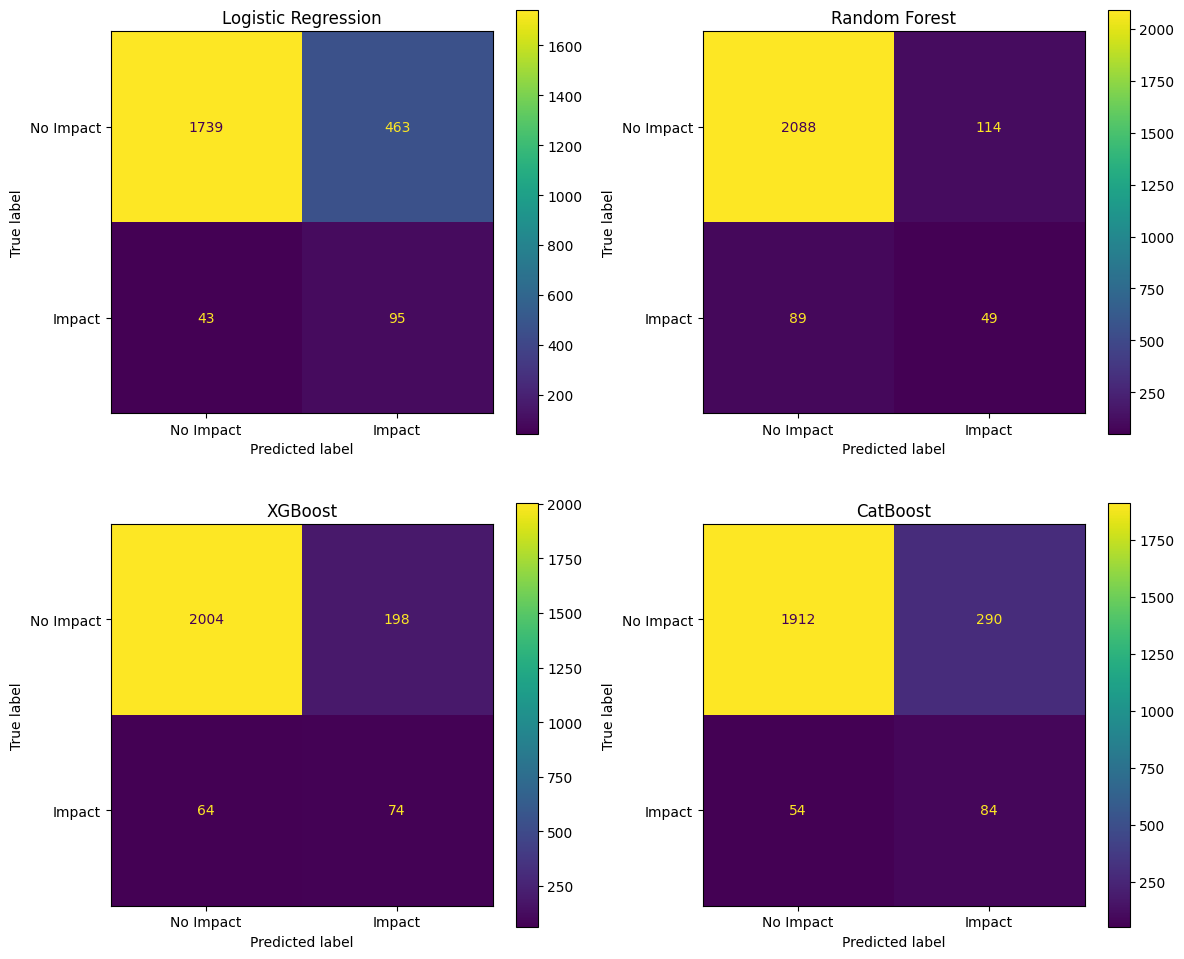

In [46]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Impact", "Impact"]
    ).plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

#Simple Baseline Model

In [47]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("Baseline Model Performance")
print("--------------------------")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-Score :", round(baseline_f1, 4))

Baseline Model Performance
--------------------------
Accuracy : 0.941
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0


#Add Baseline to Comparison

In [48]:
baseline_result = pd.DataFrame([{
    "Model": "Dummy Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "ROC-AUC": np.nan
}])

all_results = pd.concat(
    [
        results_df,
        baseline_result
    ],
    ignore_index=True
)

all_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.783761,0.170251,0.688406,0.272989,0.805375
1,Random Forest,0.913248,0.300613,0.355072,0.325581,0.855795
2,XGBoost,0.888034,0.272059,0.536232,0.360976,0.848191
3,CatBoost,0.852991,0.224599,0.608696,0.328125,0.856129
4,Dummy Baseline,0.941026,0.000000,0.000000,0.000000,NaN


#Model Comparison Chart

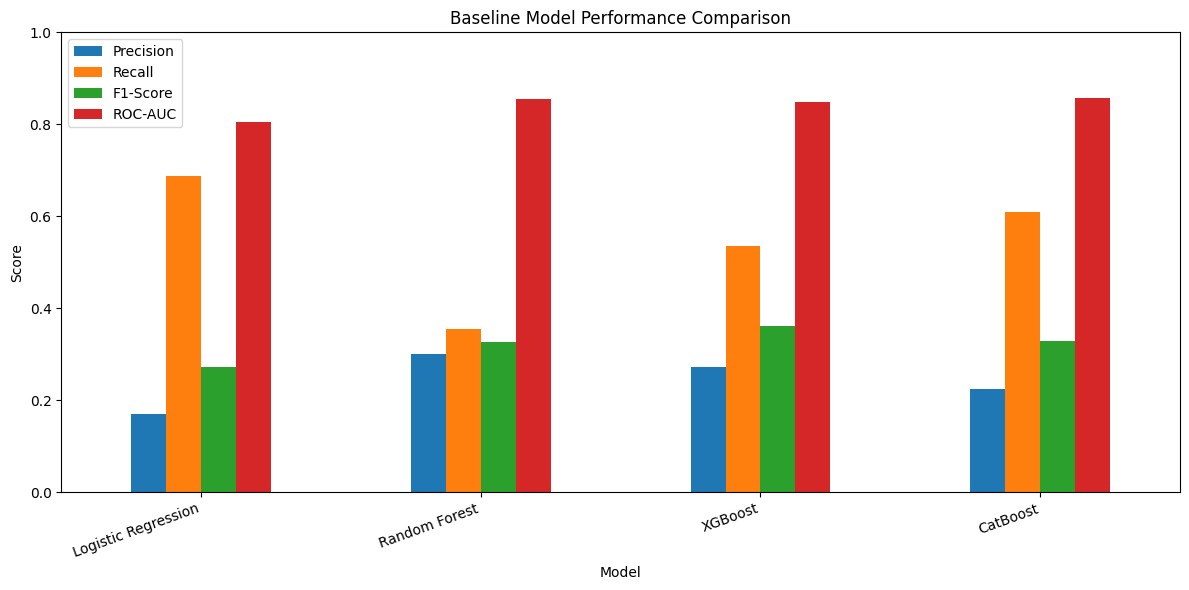

In [49]:
comparison_plot = results_df.set_index("Model")[
    [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Baseline Model Performance Comparison"
)

plt.ylabel("Score")

plt.xlabel("Model")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

#ROC Curves

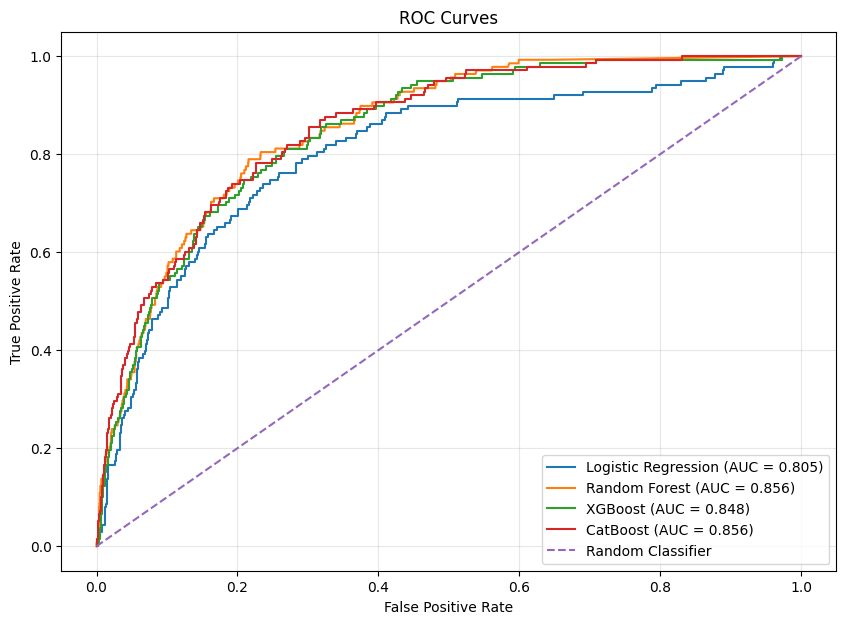

In [50]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

#Threshold Analysis

In [51]:
thresholds_to_test = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    for threshold in thresholds_to_test:

        y_pred_threshold = (
            y_prob >= threshold
        ).astype(int)

        precision = precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        threshold_results.append({
            "Model": name,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,Model,Threshold,Precision,Recall,F1-Score
0,Logistic Regression,0.10,0.063143,0.978261,0.118629
1,Logistic Regression,0.15,0.064659,0.949275,0.121072
2,Logistic Regression,0.20,0.070060,0.927536,0.130280
3,Logistic Regression,0.25,0.081448,0.913043,0.149555
4,Logistic Regression,0.30,0.100243,0.898551,0.180364


#Find Best Threshold for Each Model

In [52]:
best_thresholds = (
    threshold_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .groupby("Model")
    .first()
    .reset_index()
)

best_thresholds

,Model,Threshold,Precision,Recall,F1-Score
0,CatBoost,0.70,0.320755,0.492754,0.388571
1,Logistic Regression,0.70,0.251969,0.463768,0.326531
2,Random Forest,0.35,0.261017,0.557971,0.355658
3,XGBoost,0.55,0.282258,0.507246,0.362694


#Plot F1 Against Threshold

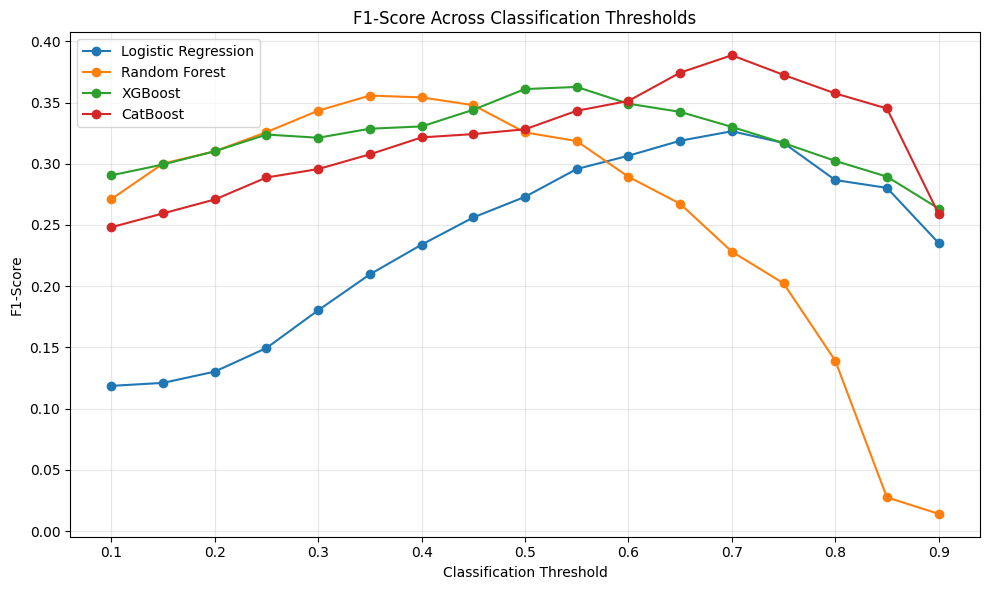

In [53]:
plt.figure(figsize=(10, 6))

for model_name in models.keys():

    model_data = threshold_df[
        threshold_df["Model"] == model_name
    ]

    plt.plot(
        model_data["Threshold"],
        model_data["F1-Score"],
        marker="o",
        label=model_name
    )

plt.xlabel("Classification Threshold")

plt.ylabel("F1-Score")

plt.title(
    "F1-Score Across Classification Thresholds"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#Select the Best Baseline Model

In [54]:
best_model_name = (
    results_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = models[
    best_model_name
]

print(
    "Best baseline model:",
    best_model_name
)

print(
    "F1-Score:",
    round(
        results_df[
            results_df["Model"] == best_model_name
        ]["F1-Score"].iloc[0],
        4
    )
)

Best baseline model: XGBoost
F1-Score: 0.361


#Best Model Summary

In [55]:
best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("BEST BASELINE MODEL")
print("-------------------")

print("Model      :", best_model_name)
print("Accuracy   :", round(best_result["Accuracy"], 4))
print("Precision  :", round(best_result["Precision"], 4))
print("Recall     :", round(best_result["Recall"], 4))
print("F1-Score   :", round(best_result["F1-Score"], 4))
print("ROC-AUC    :", round(best_result["ROC-AUC"], 4))

BEST BASELINE MODEL
-------------------
Model      : XGBoost
Accuracy   : 0.888
Precision  : 0.2721
Recall     : 0.5362
F1-Score   : 0.361
ROC-AUC    : 0.8482


#Save Results

In [56]:
results_df.to_csv(
    "baseline_model_results.csv",
    index=False
)

threshold_df.to_csv(
    "threshold_analysis_results.csv",
    index=False
)

best_thresholds.to_csv(
    "best_thresholds.csv",
    index=False
)

print("Model evaluation results saved successfully.")

Model evaluation results saved successfully.


#Final Modelling Conclusion

In [57]:
print("MODELLING STAGE COMPLETED")
print("--------------------------")

print("Models evaluated:")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. XGBoost")
print("4. CatBoost")

print("\nEvaluation metrics:")
print("Precision")
print("Recall")
print("F1-Score")
print("ROC-AUC")
print("Confusion Matrix")

print("\nBest baseline model:")
print(best_model_name)

print("\nThe selected model is ready for the next")
print("stage: Explainable AI using SHAP.")

MODELLING STAGE COMPLETED
--------------------------
Models evaluated:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. CatBoost

Evaluation metrics:
Precision
Recall
F1-Score
ROC-AUC
Confusion Matrix

Best baseline model:
XGBoost

The selected model is ready for the next
stage: Explainable AI using SHAP.


In [58]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Positive class in training:", y_train.mean())
print("Positive class in testing:", y_test.mean())

Training data: (8640, 20)
Testing data: (2340, 20)
Positive class in training: 0.0855324074074074
Positive class in testing: 0.05897435897435897


#Import tuning libraries

In [59]:
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

#Create a temporal validation split

In [60]:
split_point = int(len(X_train) * 0.8)

X_train_tune = X_train.iloc[:split_point]
y_train_tune = y_train.iloc[:split_point]

X_val = X_train.iloc[split_point:]
y_val = y_train.iloc[split_point:]

print("Tuning training data:", X_train_tune.shape)
print("Validation data:", X_val.shape)

Tuning training data: (6912, 20)
Validation data: (1728, 20)


#XGBoost tuning

In [61]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 5],
    "scale_pos_weight": [1, 2, 4, 6, 8]
}

#Run XGBoost search

In [62]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=25,
    scoring="f1",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_tune, y_train_tune)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1-score:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGBoost parameters:
{'subsample': 0.85, 'scale_pos_weight': 8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.85}

Best CV F1-score:
0.4561959567271086


#Train the tuned XGBoost

In [63]:
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

print("Tuned XGBoost training completed.")

Tuned XGBoost training completed.


#Get XGBoost validation probabilities



In [64]:
xgb_val_prob = best_xgb.predict_proba(X_val)[:, 1]

print("Validation probabilities generated.")

Validation probabilities generated.


#Find the best XGBoost threshold

In [65]:
threshold_results_xgb = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (xgb_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)

    threshold_results_xgb.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

xgb_threshold_df = pd.DataFrame(threshold_results_xgb)

print(xgb_threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.140977  1.000000  0.247117
1        0.15   0.150301  1.000000  0.261324
2        0.20   0.158562  1.000000  0.273723
3        0.25   0.171625  1.000000  0.292969
4        0.30   0.184275  1.000000  0.311203
5        0.35   0.197889  1.000000  0.330396
6        0.40   0.216763  1.000000  0.356295
7        0.45   0.233438  0.986667  0.377551
8        0.50   0.261484  0.986667  0.413408
9        0.55   0.286822  0.986667  0.444444
10       0.60   0.304167  0.973333  0.463492
11       0.65   0.328767  0.960000  0.489796
12       0.70   0.348485  0.920000  0.505495
13       0.75   0.369318  0.866667  0.517928
14       0.80   0.402778  0.773333  0.529680
15       0.85   0.383178  0.546667  0.450549
16       0.90   0.488889  0.293333  0.366667


#Select best XGBoost threshold

In [66]:
best_xgb_threshold = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Best XGBoost threshold:", best_xgb_threshold)

Best XGBoost threshold: 0.8000000000000002


#Final XGBoost evaluation

In [67]:
xgb_test_prob = best_xgb.predict_proba(X_test)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= best_xgb_threshold
).astype(int)

xgb_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_precision = precision_score(y_test, xgb_test_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_test_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_test_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_test_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_test_prob)

print("TUNED XGBOOST RESULTS")
print("---------------------")
print("Threshold:", best_xgb_threshold)
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1-score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)
print("PR-AUC   :", xgb_pr_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_test_pred))

TUNED XGBOOST RESULTS
---------------------
Threshold: 0.8000000000000002
Accuracy : 0.9358974358974359
Precision: 0.4375
Recall   : 0.30434782608695654
F1-score : 0.358974358974359
ROC-AUC  : 0.8697379852308178
PR-AUC   : 0.3536176594661838

Confusion Matrix:
[[2148   54]
 [  96   42]]


#CatBoost tuning

In [69]:
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=0,
    thread_count=-1
)

cat_params = {
    "iterations": [200, 300, 400, 500],
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
    "subsample": [0.7, 0.85, 1.0],
    "random_strength": [0, 1, 2],
    "class_weights": [
        [1, 1],
        [1, 2],
        [1, 4],
        [1, 6],
        [1, 8]
    ]
}

#Run CatBoost search

In [70]:
cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=25,
    scoring="f1",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train_tune, y_train_tune)

print("Best CatBoost parameters:")
print(cat_search.best_params_)

print("\nBest CV F1-score:")
print(cat_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CatBoost parameters:
{'subsample': 1.0, 'random_strength': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 200, 'depth': 4, 'class_weights': [1, 8]}

Best CV F1-score:
0.4697834409633166


#Train tuned CatBoost

In [71]:
best_cat = CatBoostClassifier(
    **cat_search.best_params_,
    loss_function="Logloss",
    random_seed=42,
    verbose=0,
    thread_count=-1
)

best_cat.fit(X_train, y_train)

print("Tuned CatBoost training completed.")

Tuned CatBoost training completed.


#CatBoost validation probabilities

In [72]:
cat_val_prob = best_cat.predict_proba(X_val)[:, 1]

print("Validation probabilities generated.")

Validation probabilities generated.


#CatBoost threshold tuning

In [73]:
threshold_results_cat = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (cat_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)

    threshold_results_cat.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

cat_threshold_df = pd.DataFrame(threshold_results_cat)

print(cat_threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.127768  1.000000  0.226586
1        0.15   0.139925  1.000000  0.245499
2        0.20   0.148515  1.000000  0.258621
3        0.25   0.159236  1.000000  0.274725
4        0.30   0.168161  1.000000  0.287908
5        0.35   0.181159  1.000000  0.306748
6        0.40   0.192208  0.986667  0.321739
7        0.45   0.206704  0.986667  0.341801
8        0.50   0.231975  0.986667  0.375635
9        0.55   0.259649  0.986667  0.411111
10       0.60   0.287402  0.973333  0.443769
11       0.65   0.318584  0.960000  0.478405
12       0.70   0.336683  0.893333  0.489051
13       0.75   0.339506  0.733333  0.464135
14       0.80   0.356643  0.680000  0.467890
15       0.85   0.342342  0.506667  0.408602
16       0.90   0.428571  0.160000  0.233010


#Select best CatBoost threshold

In [74]:
best_cat_threshold = cat_threshold_df.loc[
    cat_threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Best CatBoost threshold:", best_cat_threshold)

Best CatBoost threshold: 0.7000000000000002


#Final CatBoost evaluation

In [75]:
cat_test_prob = best_cat.predict_proba(X_test)[:, 1]

cat_test_pred = (
    cat_test_prob >= best_cat_threshold
).astype(int)

cat_accuracy = accuracy_score(y_test, cat_test_pred)
cat_precision = precision_score(y_test, cat_test_pred, zero_division=0)
cat_recall = recall_score(y_test, cat_test_pred, zero_division=0)
cat_f1 = f1_score(y_test, cat_test_pred, zero_division=0)
cat_roc_auc = roc_auc_score(y_test, cat_test_prob)
cat_pr_auc = average_precision_score(y_test, cat_test_prob)

print("TUNED CATBOOST RESULTS")
print("----------------------")
print("Threshold:", best_cat_threshold)
print("Accuracy :", cat_accuracy)
print("Precision:", cat_precision)
print("Recall   :", cat_recall)
print("F1-score :", cat_f1)
print("ROC-AUC  :", cat_roc_auc)
print("PR-AUC   :", cat_pr_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, cat_test_pred))

TUNED CATBOOST RESULTS
----------------------
Threshold: 0.7000000000000002
Accuracy : 0.9081196581196581
Precision: 0.3103448275862069
Recall   : 0.45652173913043476
F1-score : 0.36950146627565983
ROC-AUC  : 0.8724298727112374
PR-AUC   : 0.3610985721938971

Confusion Matrix:
[[2062  140]
 [  75   63]]


#Compare tuned models

In [76]:
comparison = pd.DataFrame({
    "Model": [
        "Tuned XGBoost",
        "Tuned CatBoost"
    ],
    "Threshold": [
        best_xgb_threshold,
        best_cat_threshold
    ],
    "Accuracy": [
        xgb_accuracy,
        cat_accuracy
    ],
    "Precision": [
        xgb_precision,
        cat_precision
    ],
    "Recall": [
        xgb_recall,
        cat_recall
    ],
    "F1": [
        xgb_f1,
        cat_f1
    ],
    "ROC-AUC": [
        xgb_roc_auc,
        cat_roc_auc
    ],
    "PR-AUC": [
        xgb_pr_auc,
        cat_pr_auc
    ]
})

comparison

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.8,0.935897,0.437500,0.304348,0.358974,0.869738,0.353618
1,Tuned CatBoost,0.7,0.908120,0.310345,0.456522,0.369501,0.872430,0.361099


#Add your old baseline results

In [77]:
baseline_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Baseline CatBoost",
        "Baseline Random Forest",
        "Tuned XGBoost",
        "Tuned CatBoost"
    ],
    "Accuracy": [
        np.nan,
        np.nan,
        0.9132,
        xgb_accuracy,
        cat_accuracy
    ],
    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        xgb_precision,
        cat_precision
    ],
    "Recall": [
        0.5362,
        0.6087,
        0.3551,
        xgb_recall,
        cat_recall
    ],
    "F1": [
        0.361,
        np.nan,
        np.nan,
        xgb_f1,
        cat_f1
    ],
    "ROC-AUC": [
        0.848,
        0.856,
        np.nan,
        xgb_roc_auc,
        cat_roc_auc
    ],
    "PR-AUC": [
        np.nan,
        np.nan,
        np.nan,
        xgb_pr_auc,
        cat_pr_auc
    ]
})

baseline_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline XGBoost,NaN,NaN,0.536200,0.361000,0.848000,NaN
1,Baseline CatBoost,NaN,NaN,0.608700,NaN,0.856000,NaN
2,Baseline Random Forest,0.913200,NaN,0.355100,NaN,NaN,NaN
3,Tuned XGBoost,0.935897,0.437500,0.304348,0.358974,0.869738,0.353618
4,Tuned CatBoost,0.908120,0.310345,0.456522,0.369501,0.872430,0.361099


#Confusion matrices

In [78]:
print("Tuned XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_test_pred))

print("\nTuned CatBoost Confusion Matrix:")
print(confusion_matrix(y_test, cat_test_pred))

Tuned XGBoost Confusion Matrix:
[[2148   54]
 [  96   42]]

Tuned CatBoost Confusion Matrix:
[[2062  140]
 [  75   63]]


#Select the final candidate

In [79]:
final_comparison = comparison.sort_values(
    by=["F1", "Recall"],
    ascending=False
)

print("Final ranking:")
print(final_comparison)

best_model_name = final_comparison.iloc[0]["Model"]

print("\nSelected baseline candidate:", best_model_name)

Final ranking:
            Model  Threshold  Accuracy  Precision    Recall        F1  \
1  Tuned CatBoost        0.7  0.908120   0.310345  0.456522  0.369501   
0   Tuned XGBoost        0.8  0.935897   0.437500  0.304348  0.358974   

    ROC-AUC    PR-AUC  
1  0.872430  0.361099  
0  0.869738  0.353618  

Selected baseline candidate: Tuned CatBoost


#Final comparison with all required metrics

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

final_comparison = pd.DataFrame({
    "Model": [
        "Tuned XGBoost",
        "Tuned CatBoost"
    ],

    "Threshold": [
        best_xgb_threshold,
        best_cat_threshold
    ],

    "Accuracy": [
        xgb_accuracy,
        cat_accuracy
    ],

    "Precision": [
        xgb_precision,
        cat_precision
    ],

    "Recall": [
        xgb_recall,
        cat_recall
    ],

    "F1": [
        xgb_f1,
        cat_f1
    ],

    "ROC-AUC": [
        xgb_roc_auc,
        cat_roc_auc
    ],

    "PR-AUC": [
        xgb_pr_auc,
        cat_pr_auc
    ]
})

final_comparison = final_comparison.sort_values(
    by=["F1", "Recall"],
    ascending=False
).reset_index(drop=True)

display(final_comparison)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned CatBoost,0.7,0.908120,0.310345,0.456522,0.369501,0.872430,0.361099
1,Tuned XGBoost,0.8,0.935897,0.437500,0.304348,0.358974,0.869738,0.353618


#Select the final candidate

In [81]:
best_final_model_name = final_comparison.iloc[0]["Model"]

print("FINAL MODEL CANDIDATE")
print("---------------------")
print(best_final_model_name)

print("\nSelection is based primarily on F1-score,")
print("with Recall considered important because this is a flood-impact DSS.")

FINAL MODEL CANDIDATE
---------------------
Tuned CatBoost

Selection is based primarily on F1-score,
with Recall considered important because this is a flood-impact DSS.


#Final confusion matrix

In [82]:
if best_final_model_name == "Tuned XGBoost":
    final_pred = (xgb_test_prob >= best_xgb_threshold).astype(int)
else:
    final_pred = (cat_test_prob >= best_cat_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[2062  140]
 [  75   63]]


#Final classification report



In [83]:
print("FINAL MODEL CLASSIFICATION REPORT")
print("----------------------------------")

print(
    classification_report(
        y_test,
        final_pred,
        digits=4,
        zero_division=0
    )
)

FINAL MODEL CLASSIFICATION REPORT
----------------------------------
              precision    recall  f1-score   support

           0     0.9649    0.9364    0.9504      2202
           1     0.3103    0.4565    0.3695       138

    accuracy                         0.9081      2340
   macro avg     0.6376    0.6965    0.6600      2340
weighted avg     0.9263    0.9081    0.9162      2340



#Save the final model

In [84]:
if best_final_model_name == "Tuned XGBoost":
    final_model = best_xgb
    final_threshold = best_xgb_threshold
else:
    final_model = best_cat
    final_threshold = best_cat_threshold

joblib.dump(
    final_model,
    "final_flood_impact_model.pkl"
)

print("Final model saved successfully.")
print("Model:", best_final_model_name)
print("Threshold:", final_threshold)

Final model saved successfully.
Model: Tuned CatBoost
Threshold: 0.7000000000000002


#Save final results

In [85]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final modelling results saved successfully.")

Final modelling results saved successfully.
